In [1]:
# %matplotlib widget
import os
import sys
import numpy as np
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import math
from IPython.display import HTML
from tqdm import tqdm
import random
from numpy.lib import recfunctions as rfn
import multiprocessing

from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.spatial import KDTree
from scipy.interpolate import interpn
# import cupy as cp
import time
import numba as nb

# 画图部分
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

# ROC曲线部分
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

# 插值
import torch
import torch.cuda as cuda
from scipy.interpolate import griddata

# 系数拟合部分
from scipy.optimize import curve_fit
from sklearn import svm


# 概率比较部分
from scipy.special import gammaln
import torch.distributions as dist

# 位置重建函数
import sys
sys.path.append('..')
import position_rec as pos

import DE
from DE import DESimulation
import importlib

# from thundersvm import SVC

Trans into torch tensor input


In [2]:
voltage = np.array([32,96,128,64,64,64,64,64,64,64,64,32])
gamma_array = np.arange(0.01,0.07,0.001)
zongbeishu_list = []
for gamma in gamma_array:
    beishu = voltage * gamma
    zongbeishu = np.exp(np.sum(np.log(beishu)))
    zongbeishu_list.append(zongbeishu / 1e6)

In [3]:
zongbeishu_list = np.array(zongbeishu_list)
gamma = gamma_array[zongbeishu_list == 5.132829921341283]
beishu = voltage * gamma
current = 0.032
current_list = []
current_list.append(current)

for dy in beishu:
    current = current * dy
    current_list.append(current)
current_list

[0.032,
 0.05939199999999996,
 0.33069465599999953,
 2.455077126143995,
 9.113246292246503,
 33.828370236819,
 125.57091031907204,
 466.1192191043951,
 1730.2345413155133,
 6422.630617363181,
 23840.804851652112,
 88497.06760933257,
 164250.55748292114]

In [4]:
importlib.reload(DE)
importlib.reload(plt)
from DE import DESimulation

In [5]:
def rndm(a, b, g, size=1):
    """Power-law gen for pdf(x)\propto x^{g-1} for a<=x<=b"""
    r = np.random.random(size=size)
    ag, bg = a**g, b**g
    return (ag + (bg - ag)*r)**(1./g)

def dense_muon_gen(modified_merged_muon_array, interp_num, event_time, dead_time_ratio):
    '''生成dense_muon_points数据, 为保证速度，从muon track的首尾线性插值，并且能量均匀分布'''

    # 定义每个元素的类型
    element_types = [('eventId', '<i4'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'),
                     ('zd', '<f8'), ('muon_time', '<f8'), ('num_e', '<u4'), ('num_e_delayed', '<u4')]
    # 定义muon模拟数量
    muon_sim_num = (modified_merged_muon_array['eventId'][-1] + 1)
    dense_muon_points = np.zeros(
        int(muon_sim_num*interp_num), dtype=element_types)
    # 获取modified_merged_muon_array中每个eventId刷新坐标
    unique_elements, start_indices = np.unique(
        modified_merged_muon_array['eventId'], return_index=True)
    end_indices = np.concatenate(
        [start_indices[1:] - 1, np.array([len(modified_merged_muon_array)-1,])])

    start_point, end_point = modified_merged_muon_array[
        start_indices], modified_merged_muon_array[end_indices]
    gap_x = - start_point['xd'] + end_point['xd']
    gap_y = - start_point['yd'] + end_point['yd']
    gap_z = - start_point['zd'] + end_point['zd']

    # 创建长度为100的0-1之间差值数组
    arr = np.tile(np.arange(0, 100/99, 1/99), (muon_sim_num, 1))
    x_dense, y_dense, z_dense = arr * \
        gap_x[:, np.newaxis], arr * \
        gap_y[:, np.newaxis], arr * gap_z[:, np.newaxis]
    x_dense, y_dense, z_dense = x_dense + start_point['xd'][:, np.newaxis], y_dense + \
        start_point['yd'][:, np.newaxis], z_dense + \
        start_point['zd'][:, np.newaxis]

    dense_muon_points['xd'], dense_muon_points['yd'], dense_muon_points['zd'] = x_dense.flatten(
    ), y_dense.flatten(), z_dense.flatten()
    dense_muon_points['eventId'] = (
        np.arange(muon_sim_num*interp_num)/100).astype('uint32')

    # 计算每个muon沉积能量总和及电子总和

    # 提取 eventId 和 electron_num 列
    event_ids = modified_merged_muon_array['eventId']
    electron_nums = modified_merged_muon_array['electronNum']
    muon_step_energy = modified_merged_muon_array['energy']

    # 使用 numpy.unique 获取唯一 eventId 和对应的索引
    unique_event_ids, event_id_indices = np.unique(
        event_ids, return_inverse=True)

    # 使用 numpy.bincount 计算每个相同 eventId 的 electron_num 总和
    muon_electron_sum = np.bincount(event_id_indices, weights=electron_nums)
    muon_electron_energy = np.bincount(
        event_id_indices, weights=muon_step_energy)
    muon_electron_sum.astype('uint32')

    # 补全dense_muon_points中的energy，num_e以及num_e_delayed
    average_electron = (muon_electron_sum/100).astype('uint32')
    average_energy = (muon_electron_energy/100).astype('uint32')

    dense_muon_points['energy'] = average_energy[dense_muon_points['eventId']]
    dense_muon_points['num_e'] = average_electron[dense_muon_points['eventId']]
    dense_muon_points['muon_time'] = event_time[dense_muon_points['eventId']]

    # 定义残留比例
    delay_ratio = ((dense_muon_points['zd']-100) / (-1.7) / 1000 + 0.02) / 100
    delay_ratio[delay_ratio < 0.001] = 0.001
    dense_muon_points['num_e_delayed'] = dense_muon_points['num_e'] * \
        delay_ratio * dead_time_ratio

    return dense_muon_points

In [6]:
file_load_once = 10
param = 0

muon_sim = DESimulation('../sim_config/Muon_sim.yaml')

# test_cevns_sim.pe_gain_std = 2.4e6

muon_file_list = []
for i in range(file_load_once):
    # print(i)
    file_index = param * file_load_once + i
    filename = "{}muon_track.{}.npy".format(muon_sim.muon_track_file,i)
    # print(filename)
    muon_file_list.append(filename)

In [7]:
muon_file_list

['../muon_track/muon_track.0.npy',
 '../muon_track/muon_track.1.npy',
 '../muon_track/muon_track.2.npy',
 '../muon_track/muon_track.3.npy',
 '../muon_track/muon_track.4.npy',
 '../muon_track/muon_track.5.npy',
 '../muon_track/muon_track.6.npy',
 '../muon_track/muon_track.7.npy',
 '../muon_track/muon_track.8.npy',
 '../muon_track/muon_track.9.npy']

In [8]:
muon_sim.generate_muon_points(muon_file_list)

 30%|██████████████████████████████████████████████████                                                                                                                     | 3/10 [00:00<00:00, 23.89it/s]

First muon track file: ../muon_track/muon_track.0.npy


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 17.61it/s]


Last muon track file: ../muon_track/muon_track.9.npy
Number of muon events: 31255
merged_muon_array data type: [('eventId', '<i4'), ('type', 'i1'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('td', '<f8')]
dense_muon_points data type:  [('eventId', '<i4'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('muon_time', '<f8'), ('num_e', '<u4'), ('num_e_delayed', '<u4')]


In [9]:
muon_sim.dense_muon_points[muon_sim.dense_muon_points['eventId']==10]

array([(10, 853.,  28.65108108,  77.35929814,   82.77832295, 0.6716711, 42673, 25),
       (10, 853.,  27.98851635,  77.94193013,   80.36469111, 0.6716711, 42673, 25),
       (10, 853.,  27.32595161,  78.52456211,   77.95105928, 0.6716711, 42673, 25),
       (10, 853.,  26.66338688,  79.10719409,   75.53742745, 0.6716711, 42673, 25),
       (10, 853.,  26.00082215,  79.68982608,   73.12379562, 0.6716711, 42673, 25),
       (10, 853.,  25.33825741,  80.27245806,   70.71016379, 0.6716711, 42673, 25),
       (10, 853.,  24.67569268,  80.85509004,   68.29653195, 0.6716711, 42673, 25),
       (10, 853.,  24.01312795,  81.43772203,   65.88290012, 0.6716711, 42673, 25),
       (10, 853.,  23.35056321,  82.02035401,   63.46926829, 0.6716711, 42673, 25),
       (10, 853.,  22.68799848,  82.60298599,   61.05563646, 0.6716711, 42673, 25),
       (10, 853.,  22.02543374,  83.18561797,   58.64200463, 0.6716711, 42673, 25),
       (10, 853.,  21.36286901,  83.76824996,   56.22837279, 0.6716711, 4267

In [10]:
xd_list = []
yd_list = []
zd_list = []


xd = muon_sim.dense_muon_points["xd"].reshape(-1)
yd = muon_sim.dense_muon_points["yd"].reshape(-1)
zd = muon_sim.dense_muon_points["zd"].reshape(-1) - 100
e_num = muon_sim.dense_muon_points["num_e"].reshape(-1)
time = zd / -1.7
xd_list.append(xd)
yd_list.append(yd)
xd = np.concatenate(xd_list)
yd = np.concatenate(yd_list)
xi = np.stack((xd, yd), axis=1)

# 定义长度与xi相同的数组数据类型，用于存储一个通道所有事件的响应
array_dtype = np.dtype((np.float64, (len(xi),)))

def calculate_pattern(pmt_id, LCE_xs, LCE_ys, LCE_value, xi):
    # print("Interpn for channel: ", pmt_id)
    return interpn(
        (LCE_xs, LCE_ys), LCE_value[pmt_id], xi, bounds_error=False, fill_value=np.nan
    )

In [11]:
results = []
for pmt_id in tqdm(range(128)):  # 仅对顶部pmt结果进行模拟
    result = calculate_pattern(
        pmt_id,
        muon_sim.LCE_xs,
        muon_sim.LCE_ys,
        muon_sim.LCE_value_true,
        xi,
    )
    results.append(result)
    # 等待所有任务完成并获取结果
results = np.array(results)
results = results.T

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:35<00:00,  3.63it/s]


In [46]:
np.sum(results,axis = 1) * muon_sim.single_electron_gain

array([23.07041838, 23.0678918 , 23.06355894, ..., 29.86060808,
       30.32963996, 30.15563421])

In [13]:
# 遍历数组的每一行
for i in range(results.shape[0]):
    if np.isnan(results[i]).any():
        if last_non_nan_row is not None:
            results[i] = last_non_nan_row
    else:
        last_non_nan_row = results[i]

In [162]:
muon_light_pattern = (results * muon_sim.single_electron_gain * e_num[:, np.newaxis])

In [163]:
ch_id = 52
muon_event = 2500

ch_waveform = muon_light_pattern[muon_event*100:muon_event*100+100, ch_id]
muon_waveform = muon_light_pattern[muon_event*100:muon_event*100+100]
ch_time_index = time[muon_event*100:muon_event*100+100]
duration = ch_time_index[-1] - ch_time_index[0]
sample_dt = ch_time_index[1] - ch_time_index[0]
# ch_waveform,ch_time_index

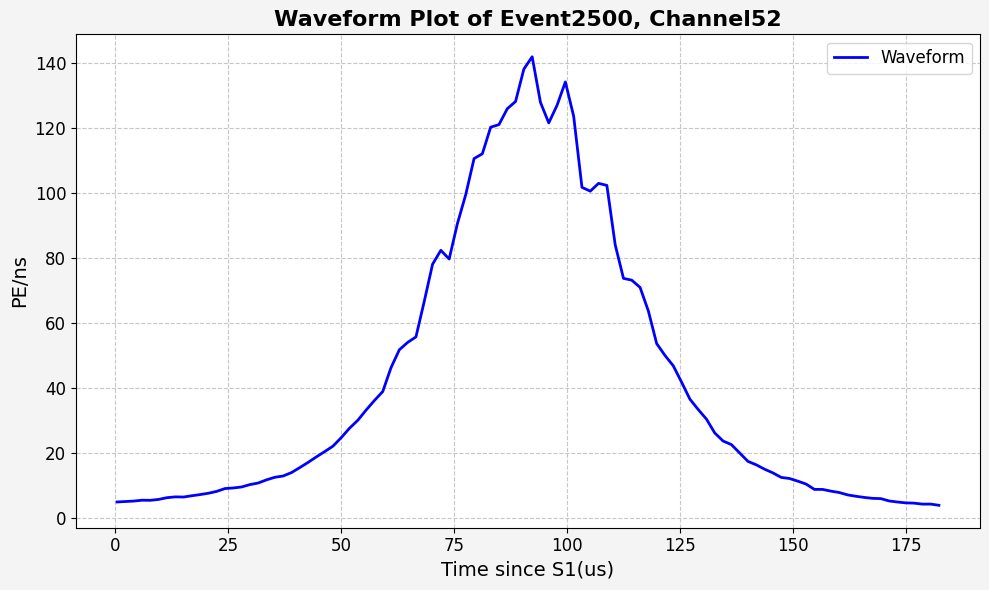

In [164]:
# 创建图形和坐标轴对象
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制波形，设置线条颜色、样式和宽度
ax.plot(ch_time_index, ch_waveform / sample_dt / 1000, color='blue', linestyle='-', linewidth=2, label='Waveform')

# 添加 x 轴和 y 轴标签
ax.set_xlabel('Time since S1(us)', fontsize=14)
ax.set_ylabel('PE/ns', fontsize=14)

# 添加标题
ax.set_title(f'Waveform Plot of Event{muon_event}, Channel{ch_id}', fontsize=16, fontweight='bold')

# 设置 x 轴和 y 轴的刻度字体大小
ax.tick_params(axis='both', which='major', labelsize=12)

# 添加网格线
ax.grid(True, linestyle='--', alpha=0.7)

# 添加图例
ax.legend(fontsize=12)

# 设置图形的背景颜色
fig.patch.set_facecolor('#f4f4f4')

# 自动调整布局
plt.tight_layout()

# 显示图形
plt.savefig("../figure/Waveform_example_ch{ch_id}.png")
plt.show()

In [165]:
import matplotlib.cm as cm
def pattern_plot(phe_pmt, electron = [] , pos_recons = [], pmt_info = muon_sim.pmt_info,title = "",savefig = False):
    artists = list()
    cmap = mpl.cm.viridis
    # 定义灰度色图
    # cmap = cm.get_cmap("YlOrRd")
    norm = mpl.colors.LogNorm(vmin=phe_pmt[~np.isnan(phe_pmt)].min(), vmax=phe_pmt[~np.isnan(phe_pmt)].max(), clip=True)
    colors = ['blue', 'green', 'yellow','red']  # 自定义颜色列表
    #norm = mpl.colors.LogNorm(vmin=1, vmax=1000, clip=True)
    fig = plt.figure(figsize=(7, 6))

    # grid = ImageGrid(fig, 111, (1,1), cbar_mode='single', axes_pad=0.1, cbar_pad=0.2)
    grid = ImageGrid(fig, 111, (1,1))

    # PMT plot
    # for pmt_id in range(64):
    #     pmt = pmt_info[pmt_id]
    #     pe_value = phe_pmt[pmt_id]
    #     # print(str(round(pe_value,2)))
    #     # grid[0].text(pmt['x'], pmt['y'], str(pmt['ChannelID']), ha='center', va='center')
    #     grid[0].text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
    #     # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc=cmap(norm(phe_pmt[pmt_id])),alpha = 0.86))
    #     # grid[0].add_patch(artists[pmt['ChannelID']])
    for pmt_id in range(64):
        pmt = pmt_info[pmt_id]
        pe_value = phe_pmt[pmt_id]
        # 检查 PMT 值并设定颜色
        # if phe_pmt[pmt_id] < 0.5:
        #     pmt_color = 'white'  # 小于0.1的通道颜色为白色
        # else:
        pmt_color = cmap(norm(phe_pmt[pmt_id]))
            # 绘制alpha为1的白色边框
        # grid[0].text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
        border = Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc='none', ec='black', lw=1, alpha=1)    
        grid[0].text(pmt['x'], pmt['y'], str(pmt['ChannelID']), ha='center', va='center')
        grid[0].add_patch(border)

        # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
        #                angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
        #                alpha=(phe_pmt[i][pmt_id] / vmax)**0))

        artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
                       angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
                       alpha=1))
        grid[0].add_patch(artists[pmt['ChannelID']])
    # event plot
    if len(electron)>0:
        grid[0].plot(electron['xd']/10, electron['yd']/10, 'o', color = 'cyan', markersize=12 ,label = 'DE Position')
  
    # recon_pos plot
    if len(pos_recons)>0:
        grid[0].plot(pos_recons['xd']/10, pos_recons['yd']/10, 'b*', markersize=12, label = 'Recon Position')
        
    # muon_point_plot
    # if muon_id_list is not None:
        # for i, muon_id in enumerate(muon_id_list):
            # color = colors[i % len(colors)]  # 从颜色列表中选择颜色
            # grid[0].plot(dense_muon_points[dense_muon_points['eventId'] == muon_id]['xd']/10, dense_muon_points[dense_muon_points['eventId'] == muon_id]['yd']/10, 'o', label="muon id: {}".format(muon_id), markersize=2, alpha=0.5, color=color)
            
    # TPC outline
    angle = np.arange(13)*np.pi/6
    outer_r = 14/np.cos(np.pi/12)
    grid[0].plot(outer_r*np.cos(angle), outer_r*np.sin(angle), c='k', lw=3)

    # Colorbar
    # grid.cbar_axes[0].colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm))

    # Other settings
    grid[0].axis('equal')
    grid[0].set_xlabel('x/cm')
    grid[0].set_ylabel('y/cm')
    # grid[0].legend(bbox_to_anchor=(1.2, 0), loc=3, borderaxespad=0, prop={'size': 7})
    # grid[0].set_title(title)
    if savefig == True: 
        plt.savefig(title+".png")
    plt.show()
    return 0

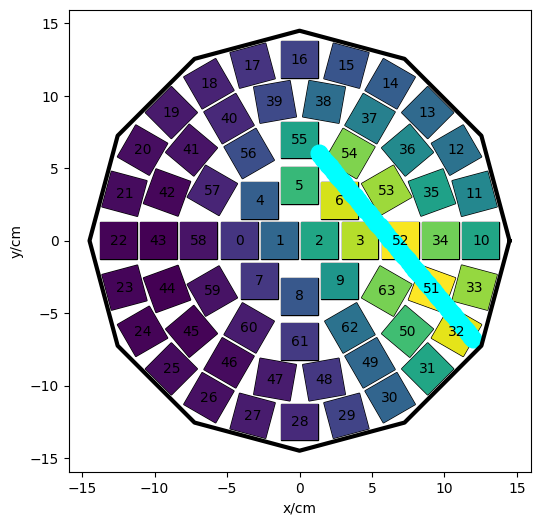

0

In [166]:
area_pattern = np.sum(muon_waveform[:99],axis = 0)

pattern_plot(area_pattern, electron = muon_sim.dense_muon_points[muon_sim.dense_muon_points['eventId']==muon_event] , pos_recons = [], pmt_info = muon_sim.pmt_info,title = f"../figure/S2_pattern_event{muon_event}",savefig = True)

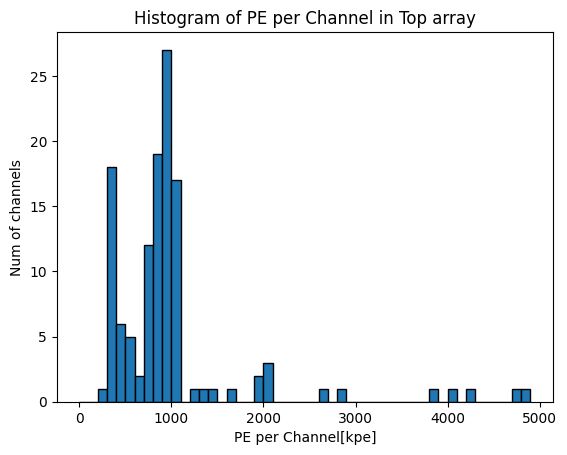

In [167]:
# 绘制直方图
plt.hist(area_pattern / 1e3, bins=np.arange(0,5e3,1e2), edgecolor='black')

# 设置图形标题和坐标轴标签
plt.title('Histogram of PE per Channel in Top array')
plt.xlabel('PE per Channel[kpe]')
plt.ylabel('Num of channels')
plt.savefig("../figure/Histogram_of_muon_pe_per_channel.png")
# 显示图形
plt.show()

In [168]:
muon_pe_per_ch = muon_light_pattern.reshape(-1, 100, 128)
muon_pe_per_ch = muon_pe_per_ch.sum(axis=1)
muon_s2_duration = np.repeat(np.abs(time.reshape(-1, 100)[:,-1] - time.reshape(-1, 100)[:,0]),128)
muon_pe_per_ch_per_ns = muon_pe_per_ch.reshape(-1) / muon_s2_duration / 1000

/tmp/ipykernel_3331995/545030531.py:4: RuntimeWarning: divide by zero encountered in divide
  muon_pe_per_ch_per_ns = muon_pe_per_ch.reshape(-1) / muon_s2_duration / 1000
/tmp/ipykernel_3331995/545030531.py:4: RuntimeWarning: invalid value encountered in divide
  muon_pe_per_ch_per_ns = muon_pe_per_ch.reshape(-1) / muon_s2_duration / 1000


In [169]:
muon_s2_dt = (np.repeat(np.abs(time.reshape(-1, 100)[:,-1] - time.reshape(-1, 100)[:,0])/ 99,12800)).reshape(-1, 128, 100)

In [185]:
muon_s2_pe_us = np.transpose(muon_light_pattern.reshape(-1, 100, 128), (0, 2, 1)) / muon_s2_dt

/tmp/ipykernel_3331995/864758106.py:1: RuntimeWarning: divide by zero encountered in divide
  muon_s2_pe_us = np.transpose(muon_light_pattern.reshape(-1, 100, 128), (0, 2, 1)) / muon_s2_dt
/tmp/ipykernel_3331995/864758106.py:1: RuntimeWarning: invalid value encountered in divide
  muon_s2_pe_us = np.transpose(muon_light_pattern.reshape(-1, 100, 128), (0, 2, 1)) / muon_s2_dt


In [189]:
muon_s2_pe_us.shape, time.reshape(-1, 100).shape

((31255, 128, 100), (31255, 100))

In [192]:
np.savez('muon_waveform.npz', waveform_time=time.reshape(-1, 100), waveform_ch_pe_us=muon_s2_pe_us)



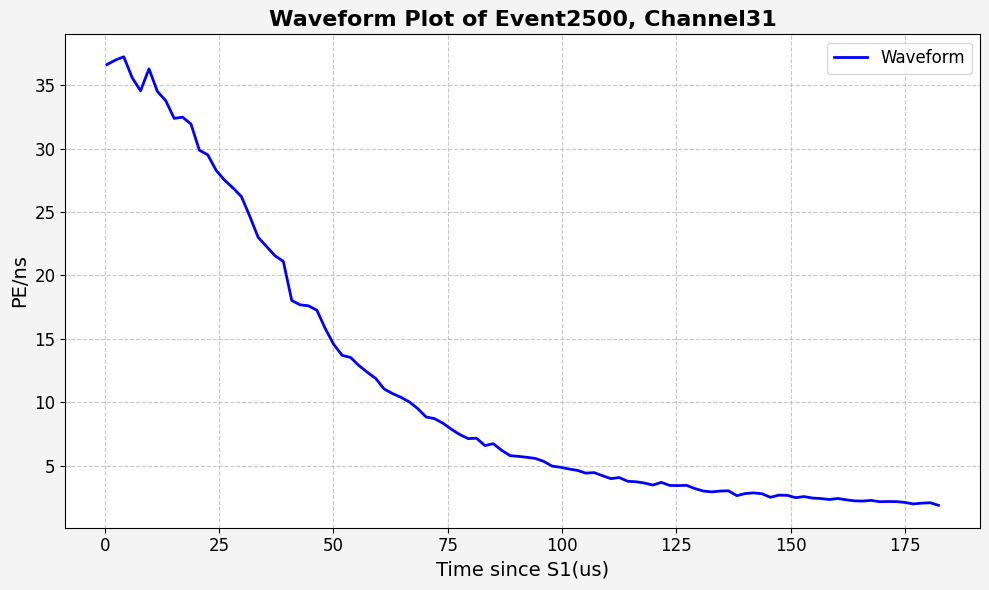

In [205]:
loaded_data = np.load('/home/data_transfer/muon_waveform.npz')

waveform_time = loaded_data['waveform_time']
waveform_ch_pe_us = loaded_data['waveform_ch_pe_us']

ch_id = 31
muon_event = 2500

# 创建图形和坐标轴对象
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制波形，设置线条颜色、样式和宽度
ax.plot(waveform_time[muon_event], waveform_ch_pe_us[muon_event][ch_id] / 1e3, color='blue', linestyle='-', linewidth=2, label='Waveform')

# 添加 x 轴和 y 轴标签
ax.set_xlabel('Time since S1(us)', fontsize=14)
ax.set_ylabel('PE/ns', fontsize=14)

# 添加标题
ax.set_title(f'Waveform Plot of Event{muon_event}, Channel{ch_id}', fontsize=16, fontweight='bold')

# 设置 x 轴和 y 轴的刻度字体大小
ax.tick_params(axis='both', which='major', labelsize=12)

# 添加网格线
ax.grid(True, linestyle='--', alpha=0.7)

# 添加图例
ax.legend(fontsize=12)

# 设置图形的背景颜色
fig.patch.set_facecolor('#f4f4f4')

# 自动调整布局
plt.tight_layout()

# 显示图形
plt.savefig(f"../figure/Waveform_example_ch{ch_id}.png")
plt.show()

In [102]:
muon_waveform_channel = muon_light_pattern / muon_s2_dt

ValueError: operands could not be broadcast together with shapes (3125500,128) (4000640,) 

In [98]:
time.shape,muon_s2_duration.shape

((3125500,), (4000640,))

In [20]:
muon_pe_per_ch.shape

(31255, 128)

In [21]:
muon_s2_ch_perate_duration = np.zeros(len(muon_pe_per_ch_per_ns),
                                       dtype = np.dtype([('num_pe_per_ns', 'f8'),('duration', 'f8')]))
muon_s2_ch_perate_duration['num_pe_per_ns'] = muon_pe_per_ch_per_ns
muon_s2_ch_perate_duration['duration'] = muon_s2_duration

In [22]:
muon_sim.dense_muon_points.reshape(-1,100)[np.abs(time.reshape(-1, 100)[:,-1] - time.reshape(-1, 100)[:,0]) == 0]

array([[(  106,  0.,  56.0934031 , -129.9084832 ,   99.8798846 ,    9.73275169,   36, 0),
        (  106,  0.,  56.0934031 , -129.9084832 ,   99.8798846 ,    9.73275169,   36, 0),
        (  106,  0.,  56.0934031 , -129.9084832 ,   99.8798846 ,    9.73275169,   36, 0),
        ...,
        (  106,  0.,  56.0934031 , -129.9084832 ,   99.8798846 ,    9.73275169,   36, 0),
        (  106,  0.,  56.0934031 , -129.9084832 ,   99.8798846 ,    9.73275169,   36, 0),
        (  106,  0.,  56.0934031 , -129.9084832 ,   99.8798846 ,    9.73275169,   36, 0)],
       [(  107,  5., -11.90775209,  141.06115112, -210.        ,   10.0151736 ,  277, 0),
        (  107,  5., -11.90775209,  141.06115112, -210.        ,   10.0151736 ,  277, 0),
        (  107,  5., -11.90775209,  141.06115112, -210.        ,   10.0151736 ,  277, 0),
        ...,
        (  107,  5., -11.90775209,  141.06115112, -210.        ,   10.0151736 ,  277, 0),
        (  107,  5., -11.90775209,  141.06115112, -210.        ,   10.015

In [23]:
muon_s2_ch_perate_duration['num_pe_per_ns']

array([1.7217079 , 1.97994418, 2.11896877, ..., 4.66643683, 4.59129564,
       4.60254291])

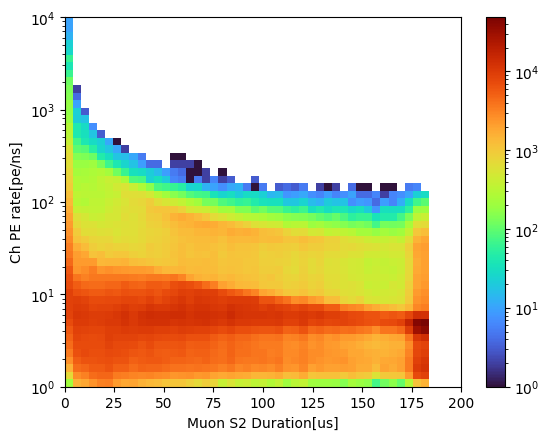

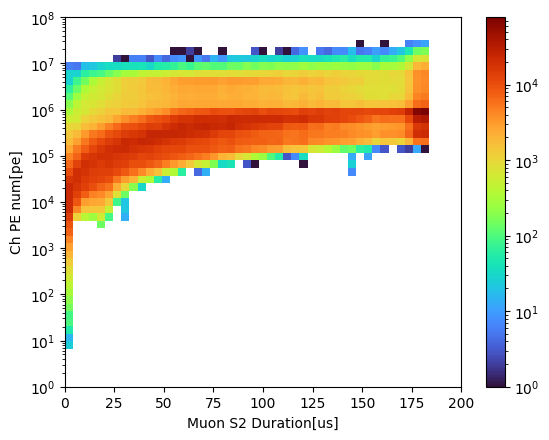

In [24]:
from matplotlib.colors import LogNorm

bins = (
    np.linspace(0, 200, 50),
    np.logspace(0, 4, 50)
)

fig, ax = plt.subplots()
count, x, y, image = ax.hist2d(
    muon_s2_ch_perate_duration['duration'],
    muon_s2_ch_perate_duration['num_pe_per_ns'],
    bins=bins,
    norm=LogNorm(),
    cmap='turbo'
)

ax.set_xlabel('Muon S2 Duration[us]')
ax.set_ylabel('Ch PE rate[pe/ns]')
# ax.set_xscale('log')
ax.set_yscale('log')

fig.colorbar(image)
plt.savefig("../figure/Ch_rate.png")
plt.show()



bins = (
    np.linspace(0, 200, 50),
    np.logspace(0, 8, 50)
)

fig, ax = plt.subplots()
count, x, y, image = ax.hist2d(
    muon_s2_ch_perate_duration['duration'],
    muon_pe_per_ch.reshape(-1),
    bins=bins,
    norm=LogNorm(),
    cmap='turbo'
)

ax.set_xlabel('Muon S2 Duration[us]')
ax.set_ylabel('Ch PE num[pe]')
# ax.set_xscale('log')
ax.set_yscale('log')

fig.colorbar(image)
plt.savefig("../figure/Ch_pe.png")
plt.show()



In [225]:
2 / 2**14

0.0001220703125